# Scenario catalog

Twenty representative driving scenarios encoded as DSL queries
and run against the corpus. The output is a ranked table of
candidate clip counts — clips that satisfy the necessary
conditions for that scenario.

> These queries are *necessary-condition filters*. They reject
> clearly-not-this-scenario candidates; a downstream classifier
> (VLM, human reviewer, heuristic) would disambiguate the
> survivors.

> See `01_quickstart.ipynb` for an introduction to the dataset
> and `02_query_dsl_tour.ipynb` for the DSL grammar.


## Setup


In [1]:
import os
from dataclasses import dataclass
from pathlib import Path

from cascade_av.dataset import CascadeDataset

# --- shared notebook styling -----------------------------------------------
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "figure.dpi": 110,
    "savefig.dpi": 110,
})

pd.options.display.max_colwidth = 110
pd.options.display.width = 140
pd.options.display.float_format = "{:.2f}".format


In [2]:
ds = CascadeDataset(Path(os.environ["CASCADE_AV_DATASET_ROOT"]))

@dataclass(frozen=True)
class Scenario:
    id: str
    title: str
    query: str


/home/horde/Projects/av-causal-dataset-tools/src/cascade_av/dataset.py:118: UserWarning: 1 clip_id(s) had multiple annotation files; kept first by filename. (Set CASCADE_AV_VERBOSE=1 for per-file detail.)
  self._scan(annotation_paths, annotation_root)


## The catalog

Twenty scenarios spanning pedestrian interactions, traffic
signals, signage, lane changes, roundabouts, and explicit
causal queries.


In [3]:
SCENARIOS = [
    Scenario("1",  "Ego drives through crosswalk while pedestrian present",
             "agent.type = ped and env.type = crosswalk and ego.action = drive"),
    Scenario("2",  "Ego yields/stops at crosswalk for a pedestrian",
             "agent.type = ped and env.type = crosswalk and ego.action in (stop, yield, decel)"),
    # Post schema-2.0.0, `jaywalk` is a parenthesized suffix on
    # `action_type` rather than a flag — enumerate the four combined
    # strings (walk/run x with/without erratic).
    Scenario("8",  "Pedestrian jaywalks; ego brakes / yields",
             'agent(type = ped, action.type in ('
             '"oxd:Walk (jaywalk)", "oxd:Walk (jaywalk, erratic)", '
             '"oxd:Run (jaywalk)", "oxd:Run (jaywalk, erratic)")) '
             "and ego.action in (stop, yield, decel)"),
    Scenario("9",  "Pedestrian crosses while ego is turning",
             "agent.type = ped and env.type = crosswalk and ego.action in (turn_left, turn_right)"),
    Scenario("12", "Cyclist mid-block in ego's path; ego defensive",
             "agent.type = cyclist and ego.action in (stop, yield, decel)"),
    Scenario("14", "Ego stops at a red traffic light (nominal)",
             "light.color = red and ego.action = stop and env.type = intersection"),
    Scenario("16", "Signal blackout — ego treats as all-way stop",
             "light.state = off and ego.action = stop and env.type = intersection"),
    Scenario("20", "Ego already in intersection when yellow begins, proceeds",
             "light(color = yellow, ego_in_on_yellow = true) and ego.action in (drive, enter, creep)"),
    Scenario("21", "Ego approaches intersection, yellow appears, ego stops",
             "light(color = yellow, on_ego_path = true) and ego.action = stop"),
    Scenario("23", "Ego stops on yellow it could have cleared safely",
             "light(color = yellow, could_have_cleared = true) and ego.action = stop"),
    Scenario("aws-basic", "Ego stops at a stop sign",
             "obj.type = stop_sign and ego.action = stop"),
    Scenario("yield-basic", "Ego yields at a yield sign",
             "obj.type = yield_sign and ego.action = yield"),
    Scenario("76", "Vehicle stopped in front of ego, ego nudges or changes lane",
             "agent(type = vehicle, pos = front, action(type in (stop, not_move))) "
             "and ego.action in (nudge, change_lane_left, change_lane_right)"),
    Scenario("lane-multi", "Multi-lane road, ego changes lane",
             "env(type = road, lanes >= 2) and ego.action in (change_lane_left, change_lane_right)"),
    Scenario("officer-stop", "Officer signaling stop; ego stops",
             "agent(type = officer, signaling = stop) and ego.action = stop"),
    Scenario("144", "Ego transits roundabout without yielding",
             "env.type = roundabout and ego.action = drive"),
    Scenario("142", "Vehicle cuts in at roundabout exit; ego brakes",
             "env.type = roundabout "
             "and agent(type = vehicle, action(type in (change_lane, change_lane_left, change_lane_right))) "
             "and ego.action in (decel, stop, nudge)"),
    Scenario("decel-because-ped", "Ego decelerates BECAUSE OF a pedestrian (causal edge)",
             "ego.action = decel because_of agent.type = ped"),
    Scenario("yellow-then-stop", "Yellow light followed by ego stop within 3s",
             "light.color = yellow then(3) ego.action = stop"),
    Scenario("red-without-stop", "During red light, ego never stops (potential violation)",
             "within light.color = red: not ego.action = stop"),
]
print(f"{len(SCENARIOS)} scenarios catalogued")


20 scenarios catalogued


## Run them all and tabulate

Sorted by candidate count, descending. The `example` column
shows one matching `clip_id` per scenario — drop it into the
annotation tool or `find_on_bundle` to inspect.


In [4]:
rows = []
for s in SCENARIOS:
    try:
        matches = ds.find(s.query)
        clips = sorted(set(matches.clips()))
        rows.append({
            "id":         s.id,
            "title":      s.title,
            "candidates": len(clips),
            "example":    clips[0] if clips else "",
        })
    except Exception as e:
        rows.append({
            "id":         s.id,
            "title":      s.title,
            "candidates": -1,
            "example":    f"ERROR: {e}",
        })

results = pd.DataFrame(rows).sort_values("candidates", ascending=False, ignore_index=True)
results


,id,title,candidates,example
0,1,Ego drives through crosswalk while pedestrian present,81,02a0d178-4f95-438f-b45a-c0f65d0d765a
1,2,Ego yields/stops at crosswalk for a pedestrian,74,02a0d178-4f95-438f-b45a-c0f65d0d765a
2,lane-multi,"Multi-lane road, ego changes lane",55,038b067d-71fc-4c1c-b634-8985a82290bb
3,red-without-stop,"During red light, ego never stops (potential violation)",49,038f960a-9b8c-4337-81ef-0ee8461b490d
4,76,"Vehicle stopped in front of ego, ego nudges or changes lane",46,038b067d-71fc-4c1c-b634-8985a82290bb
5,14,Ego stops at a red traffic light (nominal),44,028508ba-ef59-48d3-a95b-94eb92e3b063
6,8,Pedestrian jaywalks; ego brakes / yields,30,02a0d178-4f95-438f-b45a-c0f65d0d765a
7,144,Ego transits roundabout without yielding,25,0d4d2a16-b307-4be1-911e-5d194e43aac8
8,12,Cyclist mid-block in ego's path; ego defensive,22,007e4b12-d993-44af-9357-25edc7a474f8
9,9,Pedestrian crosses while ego is turning,20,050ae8d3-41ab-4f66-b5b0-0e7bf21d31ad


## Visualise the distribution

A quick bar chart of candidate counts makes it obvious which
scenarios are well-represented in the corpus and which are
scarce.


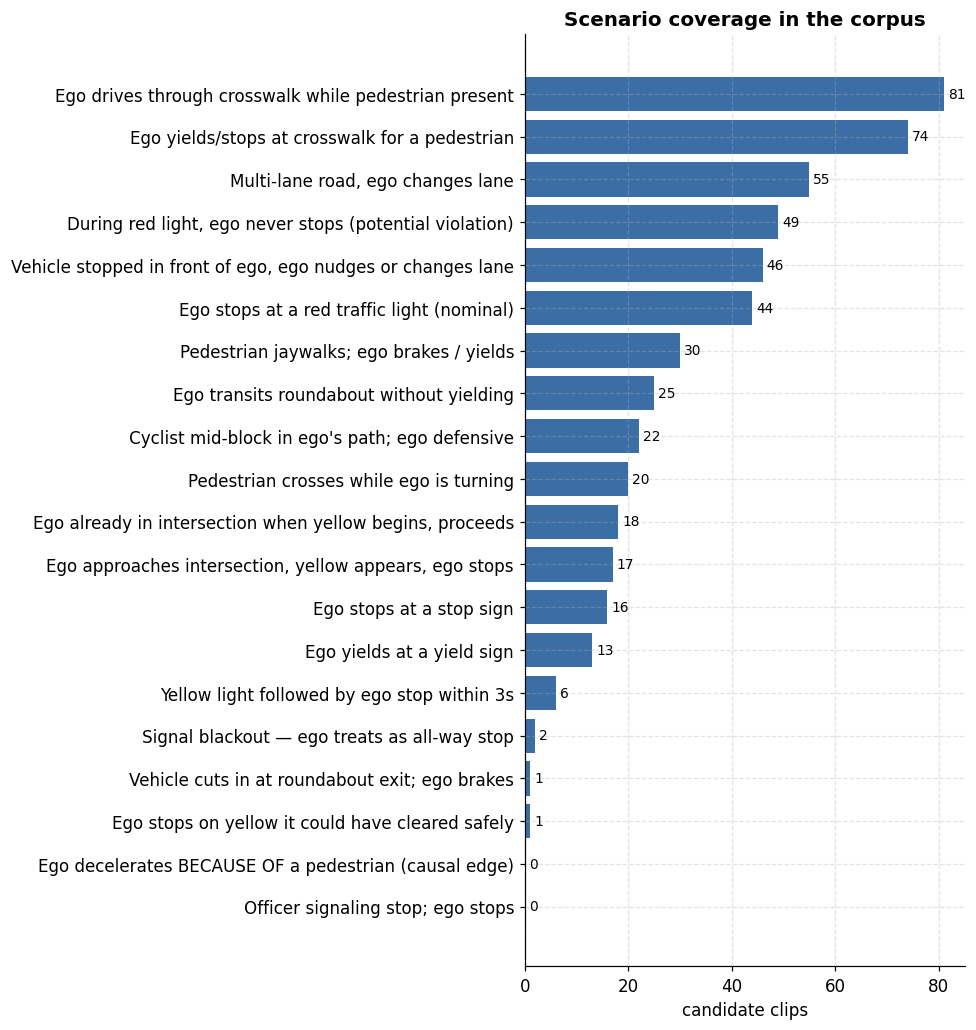

In [5]:
plot_df = results[results["candidates"] >= 0].sort_values("candidates", ascending=True)

fig, ax = plt.subplots(figsize=(9, 0.4 * len(plot_df) + 1.5))
ax.barh(plot_df["title"], plot_df["candidates"], color="#3b6ea5")
ax.set_xlabel("candidate clips")
ax.set_title("Scenario coverage in the corpus")
for i, v in enumerate(plot_df["candidates"].values):
    ax.text(v + max(plot_df["candidates"].max(), 1) * 0.01, i,
            str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()


## Dig into one scenario

Pick a scenario, list every matching clip. Swap the `target`
query for any expression you want to drill into.


In [6]:
target = (
    'agent(type = ped, action.type in ('
    '"oxd:Walk (jaywalk)", "oxd:Walk (jaywalk, erratic)", '
    '"oxd:Run (jaywalk)", "oxd:Run (jaywalk, erratic)")) '
    "and ego.action in (stop, yield, decel)"
)
clips = sorted(set(ds.find(target).clips()))

print(f"{len(clips)} clips match: {target}\n")
pd.DataFrame({"clip_id": clips})


30 clips match: agent(type = ped, action.type in ("oxd:Walk (jaywalk)", "oxd:Walk (jaywalk, erratic)", "oxd:Run (jaywalk)", "oxd:Run (jaywalk, erratic)")) and ego.action in (stop, yield, decel)



,clip_id
0,02a0d178-4f95-438f-b45a-c0f65d0d765a
1,038b067d-71fc-4c1c-b634-8985a82290bb
2,0d41ff75-4b34-4844-b467-8e47286b6d9c
3,0d973c3a-7b6a-4249-8d1d-20a24c4e2017
4,0e8fba9d-8d20-454d-ac5c-9625ca015987
5,1bb33976-0ff9-4a22-9571-5cb417e3fbd2
6,255ecbf6-c1c4-4da7-a25f-46a2bcd85a23
7,2932b306-6776-420c-99df-c8a95f9bab20
8,351674e9-7979-4b42-8a8a-4b691dce98cc
9,36fc8bdb-f666-4cf5-8802-2293eec01a5c
